In [4]:
# ============================================================
# 07 NOISY SIMULATION
# ENVIRONMENT SETUP
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector

from qiskit_aer import AerSimulator

from qiskit_aer.noise import (
    NoiseModel,
    pauli_error,
    depolarizing_error,
    ReadoutError
)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"C:\Users\heart\quantum_6g_ai"
)

RESULTS_DIR = PROJECT_ROOT / "results"

FIGURES_DIR = (
    RESULTS_DIR / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 60)
print("07 NOISY SIMULATION")
print("=" * 60)

print("Project root :", PROJECT_ROOT)
print("Results dir  :", RESULTS_DIR)
print("Figures dir  :", FIGURES_DIR)

print("\nValidation: PASS")

07 NOISY SIMULATION
Project root : C:\Users\heart\quantum_6g_ai
Results dir  : C:\Users\heart\quantum_6g_ai\results
Figures dir  : C:\Users\heart\quantum_6g_ai\results\figures

Validation: PASS


In [5]:
# ============================================================
# LOAD TRAINED MODEL AND IDEAL BASELINE
# ============================================================

TRAINED_THETA_FILE = (
    RESULTS_DIR / "trained_theta.npy"
)

TEST_Q_PATH = (
    RESULTS_DIR /
    "quantum_test_features.csv"
)

IDEAL_RESULTS_PATH = (
    RESULTS_DIR /
    "ideal_results.csv"
)

# ------------------------------------------------------------
# Load trained parameters
# ------------------------------------------------------------

trained_theta = np.load(
    TRAINED_THETA_FILE
)

# ------------------------------------------------------------
# Load test data
# ------------------------------------------------------------

test_q = pd.read_csv(
    TEST_Q_PATH
)

QUANTUM_FEATURES = [
    "Trust_Score",
    "Risk_Score",
    "Interference",
    "Resource_Load"
]

TARGET_COLUMN = "Label"

X_test_q = test_q[
    QUANTUM_FEATURES
].to_numpy(dtype=float)

y_test = test_q[
    TARGET_COLUMN
].to_numpy(dtype=int)

# ------------------------------------------------------------
# Load ideal results
# ------------------------------------------------------------

ideal_results = pd.read_csv(
    IDEAL_RESULTS_PATH
)

ideal_probabilities = (
    ideal_results[
        "Probability_Class_1"
    ].to_numpy(dtype=float)
)

ideal_predictions = (
    ideal_results[
        "Predicted_Label"
    ].to_numpy(dtype=int)
)

print("=" * 60)
print("BASELINE DATA LOADED")
print("=" * 60)

print("Test samples       :", len(X_test_q))
print("Feature shape      :", X_test_q.shape)
print("Label shape        :", y_test.shape)
print("Trained theta      :", trained_theta.shape)
print("Ideal probabilities:", ideal_probabilities.shape)
print("Ideal predictions  :", ideal_predictions.shape)

assert X_test_q.shape == (200, 4)
assert y_test.shape == (200,)
assert trained_theta.shape == (16,)
assert ideal_probabilities.shape == (200,)
assert ideal_predictions.shape == (200,)

print("\nValidation: PASS")

BASELINE DATA LOADED
Test samples       : 200
Feature shape      : (200, 4)
Label shape        : (200,)
Trained theta      : (16,)
Ideal probabilities: (200,)
Ideal predictions  : (200,)

Validation: PASS


In [6]:
# ============================================================
# SAME VQC ARCHITECTURE
# ============================================================

N_QUBITS = 4
N_LAYERS = 2
N_PARAMS = N_QUBITS * 2 * N_LAYERS

VQC_PARAMS = ParameterVector(
    "theta_noisy",
    length=N_PARAMS
)


def build_vqc(
    feature_angles,
    n_qubits=4,
    n_layers=2
):

    qc = QuantumCircuit(n_qubits)

    # --------------------------------------------------------
    # Feature encoding
    # --------------------------------------------------------

    for qubit, angle in enumerate(
        feature_angles
    ):
        qc.ry(angle, qubit)
        qc.rz(angle, qubit)

    # --------------------------------------------------------
    # Feature-map entanglement
    # --------------------------------------------------------

    for qubit in range(
        n_qubits - 1
    ):
        qc.cx(
            qubit,
            qubit + 1
        )

    # --------------------------------------------------------
    # Trainable VQC layers
    # --------------------------------------------------------

    parameter_index = 0

    for layer in range(n_layers):

        for qubit in range(n_qubits):

            qc.ry(
                VQC_PARAMS[parameter_index],
                qubit
            )

            parameter_index += 1

            qc.rz(
                VQC_PARAMS[parameter_index],
                qubit
            )

            parameter_index += 1

        for qubit in range(
            n_qubits - 1
        ):
            qc.cx(
                qubit,
                qubit + 1
            )

    return qc


print("=" * 60)
print("VQC ARCHITECTURE")
print("=" * 60)

print("Qubits     :", N_QUBITS)
print("Layers     :", N_LAYERS)
print("Parameters :", N_PARAMS)

test_circuit = build_vqc(
    X_test_q[0]
)

print(
    "Circuit parameters :",
    len(test_circuit.parameters)
)

assert len(test_circuit.parameters) == 16

print("\nValidation: PASS")

VQC ARCHITECTURE
Qubits     : 4
Layers     : 2
Parameters : 16
Circuit parameters : 16

Validation: PASS


In [7]:
# ============================================================
# CONTROLLED NOISE MODELS
# ============================================================

NOISE_STRENGTH = 0.01


def build_bit_flip_noise(
    probability=NOISE_STRENGTH
):

    noise_model = NoiseModel()

    error = pauli_error([
        ("X", probability),
        ("I", 1.0 - probability)
    ])

    noise_model.add_all_qubit_quantum_error(
        error,
        ["ry", "rz"]
    )

    return noise_model


def build_phase_flip_noise(
    probability=NOISE_STRENGTH
):

    noise_model = NoiseModel()

    error = pauli_error([
        ("Z", probability),
        ("I", 1.0 - probability)
    ])

    noise_model.add_all_qubit_quantum_error(
        error,
        ["ry", "rz"]
    )

    return noise_model


def build_depolarizing_noise(
    probability=NOISE_STRENGTH
):

    noise_model = NoiseModel()

    one_qubit_error = (
        depolarizing_error(
            probability,
            1
        )
    )

    two_qubit_error = (
        depolarizing_error(
            probability,
            2
        )
    )

    noise_model.add_all_qubit_quantum_error(
        one_qubit_error,
        ["ry", "rz"]
    )

    noise_model.add_all_qubit_quantum_error(
        two_qubit_error,
        ["cx"]
    )

    return noise_model


def build_readout_noise(
    probability=NOISE_STRENGTH
):

    noise_model = NoiseModel()

    readout_error = ReadoutError([
        [
            1.0 - probability,
            probability
        ],
        [
            probability,
            1.0 - probability
        ]
    ])

    noise_model.add_all_qubit_readout_error(
        readout_error
    )

    return noise_model


noise_models = {
    "bit_flip": build_bit_flip_noise(),
    "phase_flip": build_phase_flip_noise(),
    "depolarizing": build_depolarizing_noise(),
    "readout": build_readout_noise()
}

print("=" * 60)
print("NOISE MODELS")
print("=" * 60)

print("Noise strength :", NOISE_STRENGTH)

for name in noise_models:
    print(
        f"{name:15s}: READY"
    )

print("\nValidation: PASS")

NOISE MODELS
Noise strength : 0.01
bit_flip       : READY
phase_flip     : READY
depolarizing   : READY
readout        : READY

Validation: PASS


In [8]:
# ============================================================
# NOISY VQC PROBABILITY FUNCTION
# ============================================================

SHOTS = 1024
SEED_SIMULATOR = 42


def noisy_vqc_probability(
    feature_angles,
    parameter_values,
    noise_model,
    shots=SHOTS,
    seed=SEED_SIMULATOR
):
    """
    Execute the trained VQC with a specified
    Qiskit Aer noise model.

    Returns:
        Probability of class 1.
    """

    # --------------------------------------------------------
    # Build same VQC
    # --------------------------------------------------------

    circuit = build_vqc(
        feature_angles,
        n_qubits=N_QUBITS,
        n_layers=N_LAYERS
    )

    # --------------------------------------------------------
    # Bind trained numerical parameters
    # --------------------------------------------------------

    parameter_dict = {
        VQC_PARAMS[i]: float(parameter_values[i])
        for i in range(N_PARAMS)
    }

    bound_circuit = circuit.assign_parameters(
        parameter_dict,
        inplace=False
    )

    # --------------------------------------------------------
    # Validate parameter binding
    # --------------------------------------------------------

    if len(bound_circuit.parameters) != 0:

        raise RuntimeError(
            "Parameter binding failed.\n"
            f"Remaining parameters: "
            f"{bound_circuit.parameters}"
        )

    # --------------------------------------------------------
    # Measurement
    # --------------------------------------------------------

    measured = bound_circuit.copy()

    measured.measure_all()

    # --------------------------------------------------------
    # Noisy Aer simulator
    # --------------------------------------------------------

    simulator = AerSimulator(
        noise_model=noise_model
    )

    compiled = transpile(
        measured,
        simulator,
        optimization_level=1
    )

    # --------------------------------------------------------
    # Validate transpiled circuit
    # --------------------------------------------------------

    if len(compiled.parameters) != 0:

        raise RuntimeError(
            "Transpiled circuit still contains "
            "parameters.\n"
            f"Parameters: {compiled.parameters}"
        )

    # --------------------------------------------------------
    # Execute
    # --------------------------------------------------------

    job = simulator.run(
        compiled,
        shots=shots,
        seed_simulator=seed
    )

    result = job.result()

    counts = result.get_counts()

    # --------------------------------------------------------
    # Calculate P(q0 = 1)
    # --------------------------------------------------------

    p1 = 0.0

    for bitstring, count in counts.items():

        q0_bit = int(bitstring[-1])

        if q0_bit == 1:
            p1 += count / shots

    return p1


print("=" * 60)
print("NOISY VQC EXECUTION FUNCTION")
print("=" * 60)

print("Shots :", SHOTS)
print("Noise models :", len(noise_models))

print("\nFunction created successfully.")

NOISY VQC EXECUTION FUNCTION
Shots : 1024
Noise models : 4

Function created successfully.


In [9]:
# ============================================================
# SINGLE-SAMPLE NOISY VQC TEST
# ============================================================

print("=" * 60)
print("SINGLE-SAMPLE NOISY VQC TEST")
print("=" * 60)

sample_index = 0

print("Sample index :", sample_index)
print("True label   :", y_test[sample_index])

print("\nIdeal result:")
print(
    "P(y=1)      :",
    round(
        ideal_probabilities[sample_index],
        6
    )
)

print(
    "Prediction   :",
    ideal_predictions[sample_index]
)

print("\nNoisy results:")

single_sample_noisy = {}

for noise_name, noise_model in noise_models.items():

    probability = noisy_vqc_probability(
        X_test_q[sample_index],
        trained_theta,
        noise_model=noise_model,
        shots=SHOTS,
        seed=SEED_SIMULATOR
    )

    prediction = int(
        probability >= 0.5
    )

    single_sample_noisy[
        noise_name
    ] = probability

    print(
        f"{noise_name:15s} | "
        f"P(y=1) = {probability:.6f} | "
        f"Prediction = {prediction}"
    )

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

for probability in single_sample_noisy.values():

    assert 0.0 <= probability <= 1.0


print("\nValidation: PASS")

SINGLE-SAMPLE NOISY VQC TEST
Sample index : 0
True label   : 1

Ideal result:
P(y=1)      : 0.995117
Prediction   : 1

Noisy results:
bit_flip        | P(y=1) = 0.933594 | Prediction = 1
phase_flip      | P(y=1) = 0.995117 | Prediction = 1
depolarizing    | P(y=1) = 0.951172 | Prediction = 1
readout         | P(y=1) = 0.985352 | Prediction = 1

Validation: PASS


In [10]:
# ============================================================
# SINGLE-SAMPLE PROBABILITY SHIFT
# ============================================================

ideal_p = ideal_probabilities[
    sample_index
]

print("=" * 60)
print("SINGLE-SAMPLE NOISE IMPACT")
print("=" * 60)

print(
    "Ideal P(y=1) :",
    round(ideal_p, 6)
)

for noise_name, noisy_p in single_sample_noisy.items():

    probability_shift = (
        noisy_p - ideal_p
    )

    absolute_shift = abs(
        probability_shift
    )

    print(
        f"{noise_name:15s} | "
        f"Shift = {probability_shift:+.6f} | "
        f"Absolute = {absolute_shift:.6f}"
    )

print("\nValidation: PASS")

SINGLE-SAMPLE NOISE IMPACT
Ideal P(y=1) : 0.995117
bit_flip        | Shift = -0.061523 | Absolute = 0.061523
phase_flip      | Shift = +0.000000 | Absolute = 0.000000
depolarizing    | Shift = -0.043945 | Absolute = 0.043945
readout         | Shift = -0.009766 | Absolute = 0.009766

Validation: PASS


In [11]:
# ============================================================
# FULL NOISY VQC INFERENCE
# 200 SAMPLES × 4 NOISE MODELS
# ============================================================

noise_probabilities = {}
noise_predictions = {}

print("=" * 60)
print("FULL NOISY VQC INFERENCE")
print("=" * 60)

print("Test samples   :", len(X_test_q))
print("Noise models   :", len(noise_models))
print("Shots          :", SHOTS)
print("Noise strength :", NOISE_STRENGTH)

print(
    "\nTotal noisy evaluations :",
    len(X_test_q) * len(noise_models)
)

# ------------------------------------------------------------
# Run each noise model
# ------------------------------------------------------------

for noise_name, noise_model in noise_models.items():

    print("\n" + "-" * 60)
    print("Noise model:", noise_name)
    print("-" * 60)

    probabilities = []
    predictions = []

    for i, feature_angles in enumerate(X_test_q):

        sample_seed = (
            SEED_SIMULATOR + i
        )

        probability = noisy_vqc_probability(
            feature_angles,
            trained_theta,
            noise_model=noise_model,
            shots=SHOTS,
            seed=sample_seed
        )

        prediction = int(
            probability >= 0.5
        )

        probabilities.append(
            probability
        )

        predictions.append(
            prediction
        )

        if (i + 1) % 25 == 0:

            print(
                f"Processed "
                f"{i + 1:03d}/{len(X_test_q)}"
            )

    noise_probabilities[
        noise_name
    ] = np.asarray(
        probabilities,
        dtype=float
    )

    noise_predictions[
        noise_name
    ] = np.asarray(
        predictions,
        dtype=int
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    assert len(
        noise_probabilities[noise_name]
    ) == 200

    assert len(
        noise_predictions[noise_name]
    ) == 200

    assert np.all(
        (
            noise_probabilities[noise_name]
            >= 0.0
        )
        &
        (
            noise_probabilities[noise_name]
            <= 1.0
        )
    )

print("\n" + "=" * 60)
print("FULL NOISY INFERENCE COMPLETE")
print("=" * 60)

for noise_name in noise_models:

    print(
        f"{noise_name:15s} | "
        f"Probabilities = "
        f"{noise_probabilities[noise_name].shape} | "
        f"Predictions = "
        f"{noise_predictions[noise_name].shape}"
    )

print("\nValidation: PASS")

FULL NOISY VQC INFERENCE
Test samples   : 200
Noise models   : 4
Shots          : 1024
Noise strength : 0.01

Total noisy evaluations : 800

------------------------------------------------------------
Noise model: bit_flip
------------------------------------------------------------
Processed 025/200
Processed 050/200
Processed 075/200
Processed 100/200
Processed 125/200
Processed 150/200
Processed 175/200
Processed 200/200

------------------------------------------------------------
Noise model: phase_flip
------------------------------------------------------------
Processed 025/200
Processed 050/200
Processed 075/200
Processed 100/200
Processed 125/200
Processed 150/200
Processed 175/200
Processed 200/200

------------------------------------------------------------
Noise model: depolarizing
------------------------------------------------------------
Processed 025/200
Processed 050/200
Processed 075/200
Processed 100/200
Processed 125/200
Processed 150/200
Processed 175/200
Proce

In [12]:
# ============================================================
# IDEAL vs NOISY PERFORMANCE COMPARISON
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

comparison_rows = []

# ------------------------------------------------------------
# Ideal baseline
# ------------------------------------------------------------

ideal_accuracy = accuracy_score(
    y_test,
    ideal_predictions
)

comparison_rows.append({
    "condition": "ideal",
    "noise_strength": 0.0,
    "accuracy": ideal_accuracy,
    "error_rate": 1.0 - ideal_accuracy,
    "precision": precision_score(
        y_test,
        ideal_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        ideal_predictions,
        zero_division=0
    ),
    "f1_score": f1_score(
        y_test,
        ideal_predictions,
        zero_division=0
    )
})

# ------------------------------------------------------------
# Noisy models
# ------------------------------------------------------------

for noise_name in noise_models:

    predictions = noise_predictions[
        noise_name
    ]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    comparison_rows.append({
        "condition": noise_name,
        "noise_strength": NOISE_STRENGTH,
        "accuracy": accuracy,
        "error_rate": 1.0 - accuracy,
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

noise_comparison = pd.DataFrame(
    comparison_rows
)

print("=" * 60)
print("IDEAL vs NOISY PERFORMANCE")
print("=" * 60)

print(
    noise_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\nValidation: PASS")

IDEAL vs NOISY PERFORMANCE
   condition  noise_strength  accuracy  error_rate  precision   recall  f1_score
       ideal        0.000000  0.850000    0.150000   0.836538 0.870000  0.852941
    bit_flip        0.010000  0.850000    0.150000   0.836538 0.870000  0.852941
  phase_flip        0.010000  0.850000    0.150000   0.836538 0.870000  0.852941
depolarizing        0.010000  0.850000    0.150000   0.836538 0.870000  0.852941
     readout        0.010000  0.850000    0.150000   0.836538 0.870000  0.852941

Validation: PASS


In [13]:
# ============================================================
# NOISE-INDUCED PROBABILITY SHIFT
# ============================================================

noise_impact_rows = []

for noise_name in noise_models:

    noisy_probs = noise_probabilities[
        noise_name
    ]

    probability_shift = (
        noisy_probs
        - ideal_probabilities
    )

    absolute_shift = np.abs(
        probability_shift
    )

    mean_shift = np.mean(
        probability_shift
    )

    mean_absolute_shift = np.mean(
        absolute_shift
    )

    max_absolute_shift = np.max(
        absolute_shift
    )

    changed_predictions = np.sum(
        noise_predictions[noise_name]
        != ideal_predictions
    )

    prediction_change_rate = (
        changed_predictions
        / len(y_test)
    )

    noise_impact_rows.append({
        "noise_model": noise_name,
        "noise_strength": NOISE_STRENGTH,
        "mean_probability_shift": mean_shift,
        "mean_absolute_probability_shift":
            mean_absolute_shift,
        "max_absolute_probability_shift":
            max_absolute_shift,
        "prediction_changes":
            changed_predictions,
        "prediction_change_rate":
            prediction_change_rate
    })

noise_impact = pd.DataFrame(
    noise_impact_rows
)

print("=" * 60)
print("NOISE-INDUCED PROBABILITY IMPACT")
print("=" * 60)

print(
    noise_impact.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\nValidation: PASS")

NOISE-INDUCED PROBABILITY IMPACT
 noise_model  noise_strength  mean_probability_shift  mean_absolute_probability_shift  max_absolute_probability_shift  prediction_changes  prediction_change_rate
    bit_flip        0.010000               -0.003501                         0.036499                        0.079102                   0                0.000000
  phase_flip        0.010000                0.001582                         0.004893                        0.022461                   0                0.000000
depolarizing        0.010000               -0.001035                         0.027207                        0.062500                   0                0.000000
     readout        0.010000               -0.000410                         0.006348                        0.016602                   0                0.000000

Validation: PASS


In [14]:
# ============================================================
# SAVE NOISY EXPERIMENT RESULTS
# ============================================================

# ------------------------------------------------------------
# 1. Performance comparison
# ------------------------------------------------------------

noise_comparison_path = (
    RESULTS_DIR /
    "noise_comparison.csv"
)

noise_comparison.to_csv(
    noise_comparison_path,
    index=False
)


# ------------------------------------------------------------
# 2. Probability impact
# ------------------------------------------------------------

noise_impact_path = (
    RESULTS_DIR /
    "noise_impact.csv"
)

noise_impact.to_csv(
    noise_impact_path,
    index=False
)


# ------------------------------------------------------------
# 3. Detailed per-sample noisy results
# ------------------------------------------------------------

noisy_results = pd.DataFrame({
    "True_Label": y_test,
    "Ideal_Probability": ideal_probabilities,
    "Ideal_Prediction": ideal_predictions
})

for noise_name in noise_models:

    noisy_results[
        f"{noise_name}_Probability"
    ] = noise_probabilities[
        noise_name
    ]

    noisy_results[
        f"{noise_name}_Prediction"
    ] = noise_predictions[
        noise_name
    ]

noisy_results_path = (
    RESULTS_DIR /
    "noisy_results.csv"
)

noisy_results.to_csv(
    noisy_results_path,
    index=False
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert noise_comparison_path.exists()
assert noise_impact_path.exists()
assert noisy_results_path.exists()

assert len(noisy_results) == 200

print("=" * 60)
print("NOISY RESULTS SAVED")
print("=" * 60)

print(
    "Performance :",
    noise_comparison_path
)

print(
    "Impact      :",
    noise_impact_path
)

print(
    "Detailed    :",
    noisy_results_path
)

print("\nValidation: PASS")

NOISY RESULTS SAVED
Performance : C:\Users\heart\quantum_6g_ai\results\noise_comparison.csv
Impact      : C:\Users\heart\quantum_6g_ai\results\noise_impact.csv
Detailed    : C:\Users\heart\quantum_6g_ai\results\noisy_results.csv

Validation: PASS


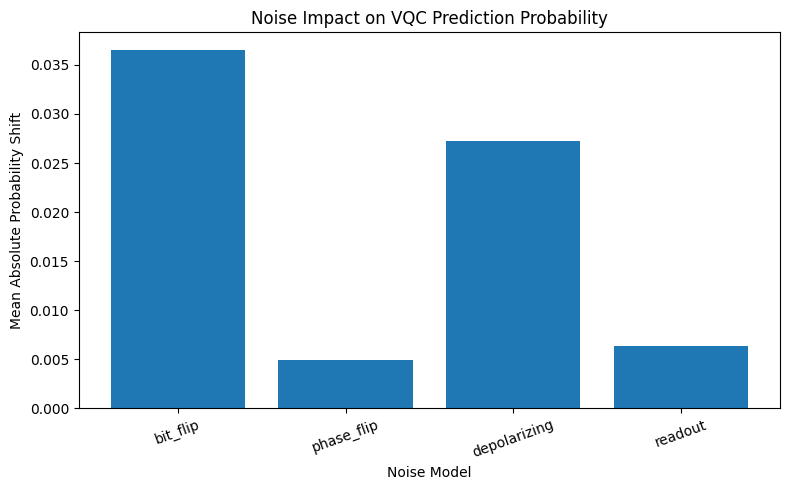

NOISE IMPACT FIGURE SAVED
File : C:\Users\heart\quantum_6g_ai\results\figures\noise_probability_impact.png

Validation: PASS


In [15]:
# ============================================================
# NOISE IMPACT - MEAN ABSOLUTE PROBABILITY SHIFT
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

noise_names = noise_impact[
    "noise_model"
].to_numpy()

shift_values = noise_impact[
    "mean_absolute_probability_shift"
].to_numpy()

ax.bar(
    noise_names,
    shift_values
)

ax.set_title(
    "Noise Impact on VQC Prediction Probability"
)

ax.set_xlabel(
    "Noise Model"
)

ax.set_ylabel(
    "Mean Absolute Probability Shift"
)

ax.tick_params(
    axis="x",
    rotation=20
)

fig.tight_layout()

noise_impact_figure = (
    FIGURES_DIR /
    "noise_probability_impact.png"
)

fig.savefig(
    noise_impact_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("=" * 60)
print("NOISE IMPACT FIGURE SAVED")
print("=" * 60)

print(
    "File :",
    noise_impact_figure
)

print("\nValidation: PASS")

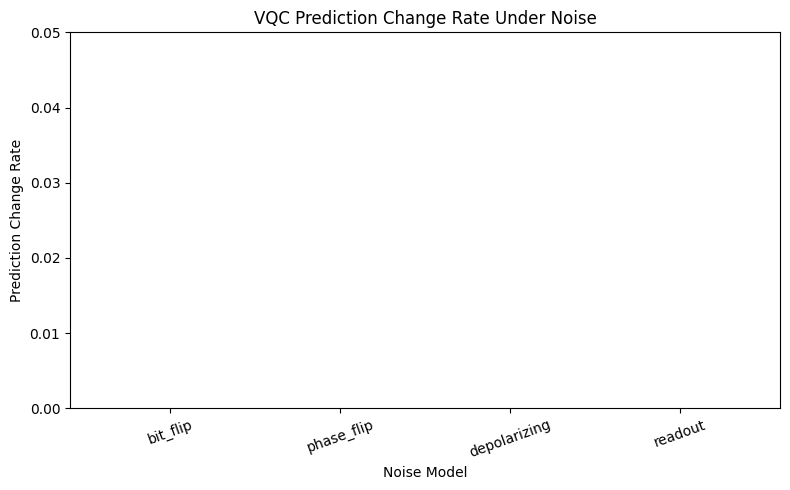

PREDICTION STABILITY FIGURE SAVED
File : C:\Users\heart\quantum_6g_ai\results\figures\noise_prediction_change_rate.png

Validation: PASS


In [16]:
# ============================================================
# PREDICTION CHANGE RATE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

change_rates = noise_impact[
    "prediction_change_rate"
].to_numpy()

ax.bar(
    noise_names,
    change_rates
)

ax.set_title(
    "VQC Prediction Change Rate Under Noise"
)

ax.set_xlabel(
    "Noise Model"
)

ax.set_ylabel(
    "Prediction Change Rate"
)

ax.set_ylim(
    0.0,
    max(0.05, change_rates.max() + 0.01)
)

ax.tick_params(
    axis="x",
    rotation=20
)

fig.tight_layout()

prediction_change_path = (
    FIGURES_DIR /
    "noise_prediction_change_rate.png"
)

fig.savefig(
    prediction_change_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("=" * 60)
print("PREDICTION STABILITY FIGURE SAVED")
print("=" * 60)

print("File :", prediction_change_path)

print("\nValidation: PASS")

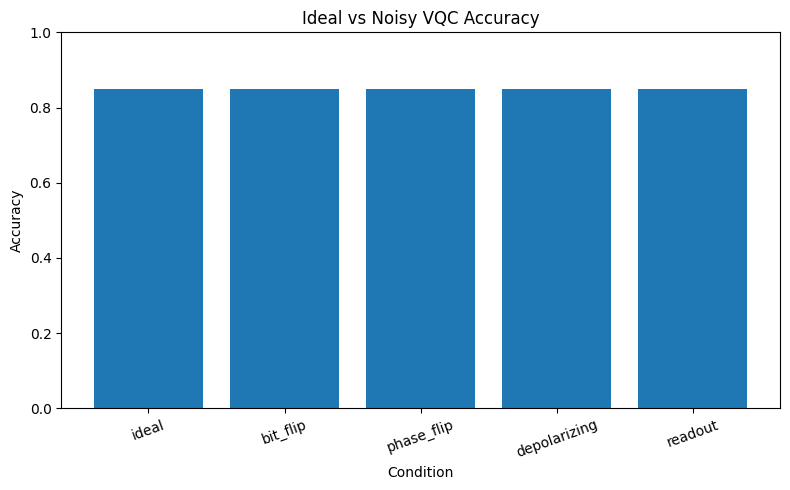

ACCURACY FIGURE SAVED
File : C:\Users\heart\quantum_6g_ai\results\figures\ideal_vs_noisy_accuracy.png

Validation: PASS


In [17]:
# ============================================================
# IDEAL vs NOISY ACCURACY
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

conditions = noise_comparison[
    "condition"
].to_numpy()

accuracies = noise_comparison[
    "accuracy"
].to_numpy()

ax.bar(
    conditions,
    accuracies
)

ax.set_title(
    "Ideal vs Noisy VQC Accuracy"
)

ax.set_xlabel(
    "Condition"
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_ylim(
    0.0,
    1.0
)

ax.tick_params(
    axis="x",
    rotation=20
)

fig.tight_layout()

accuracy_figure_path = (
    FIGURES_DIR /
    "ideal_vs_noisy_accuracy.png"
)

fig.savefig(
    accuracy_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("=" * 60)
print("ACCURACY FIGURE SAVED")
print("=" * 60)

print("File :", accuracy_figure_path)

print("\nValidation: PASS")

In [18]:
# ============================================================
# 07 NOISY SIMULATION - FINAL VALIDATION
# ============================================================

required_files = [
    RESULTS_DIR / "trained_theta.npy",
    RESULTS_DIR / "ideal_results.csv",
    RESULTS_DIR / "noise_comparison.csv",
    RESULTS_DIR / "noise_impact.csv",
    RESULTS_DIR / "noisy_results.csv",
    FIGURES_DIR / "noise_probability_impact.png",
    FIGURES_DIR / "noise_prediction_change_rate.png",
    FIGURES_DIR / "ideal_vs_noisy_accuracy.png"
]

print("=" * 60)
print("07 NOISY SIMULATION - FINAL VALIDATION")
print("=" * 60)

all_passed = True

for file_path in required_files:

    exists = file_path.exists()

    print(
        f"{'PASS' if exists else 'FAIL'} | "
        f"{file_path.name}"
    )

    if not exists:
        all_passed = False


# ------------------------------------------------------------
# Data validation
# ------------------------------------------------------------

assert len(noise_models) == 4

for noise_name in noise_models:

    assert (
        noise_probabilities[
            noise_name
        ].shape == (200,)
    )

    assert (
        noise_predictions[
            noise_name
        ].shape == (200,)
    )

assert noise_comparison.shape[0] == 5
assert noise_impact.shape[0] == 4
assert noisy_results.shape[0] == 200

assert np.all(
    (
        noisy_results.filter(
            regex="_Probability$"
        ).to_numpy()
        >= 0.0
    )
    &
    (
        noisy_results.filter(
            regex="_Probability$"
        ).to_numpy()
        <= 1.0
    )
)

if all_passed:

    print("\n" + "=" * 60)
    print("07 NOISY SIMULATION")
    print("STATUS: COMPLETE")
    print("=" * 60)

else:

    print("\nSTATUS: CHECK FAILED FILES")

07 NOISY SIMULATION - FINAL VALIDATION
PASS | trained_theta.npy
PASS | ideal_results.csv
PASS | noise_comparison.csv
PASS | noise_impact.csv
PASS | noisy_results.csv
PASS | noise_probability_impact.png
PASS | noise_prediction_change_rate.png
PASS | ideal_vs_noisy_accuracy.png

07 NOISY SIMULATION
STATUS: COMPLETE
